# Segmentación por Trials

Este notebook implementa el pipeline de decodificación neural usando SNNs con **segmentación por trials** (en lugar de ventanas fijas de 200ms).

**Fase 1:Preparacion de datos**
1. Cargar MUA_matrix (spike detection ya hecho)
2. Extraer eventos de trials del .nev
3. Extraer y procesar targets del .ns2
4. Segmentar datos por trials
5. Crear dataset y dataloaders

**Fase 2: SNN+entrenamiento**
1. Arquitectura SNN
2. Conf entrenamiento
3. Loop entrenamiento 

**Fase 3: Evluacion y resultados**
1. Curvas de entrenamiento
2. Evaluación test set (cc)
3. Visualizacion Prediccion vs Target

# FASE 1: PREPARACION DE DATOS


In [1]:
# ============================================================================
# PASO 1: CARGA DE MUA_matrix
# ============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Subset
import neo
from collections import Counter
import os

# ===== CONFIGURACIÓN DEL EXPERIMENTO =====
# exp_07 = exp_05 + ZERO-CROSSING del target (mejora visual y CCs de fuerzas):
#   - cada trial Y_trials[k] se le resta Y_trials[k, 0, :]  -> cada trial empieza en 0
#   - el paper Sec III-D explicitamente segmenta en zero-crossings
#   - verificado en Dataset.zip del autor: ratio init/max ~ 0.02
# ---
# exp_05 = replica fiel al paper / codigo de Lucas Martis:
#   - bias=False en todas las capas Linear
#   - β POR NEURONA (no escalar por capa)
#   - Split SECUENCIAL por trials (no random)
#   - Mejor modelo = MENOR val_loss (no mayor val_cc)
EXPERIMENTO_ID   = "exp_07"
EXPERIMENTO_DESC = "zero_crossing"

NORMALIZACION  = "zscore"
OFFSET_TARGET  = False
ZERO_CROSSING  = True   # NUEVO en exp_07: restar Y_trials[k,0,:] a cada trial -> zero-crossing
N_TRIALS_PLOT  = 3          # nº de trials a mostrar en la gráfica (estilo paper)
# =========================================

# Configuración de rutas
nev_path = os.path.join('..', '..', 'datos', 'i140703-001-03.nev')
ns2_path = os.path.join('..', '..', 'datos', 'i140703-001.ns2')

MUA_matrix = np.load('MUA_matrix_96channels.npy')

print(f"  MUA_matrix: {MUA_matrix.shape}") #(96 canales, 1,003,000 bins) 1 bin =1ms aproximadamente 16 minutos de grabación
print(f"  Canales: {MUA_matrix.shape[0]}")
print(f"  Bins: {MUA_matrix.shape[1]:,}")
print(f"  Duración: {MUA_matrix.shape[1] / 1000:.1f} s")
print(f"  Dtype: {MUA_matrix.dtype}")

  MUA_matrix: (96, 1003210)
  Canales: 96
  Bins: 1,003,210
  Duración: 1003.2 s
  Dtype: int8


In [2]:
# ============================================================================
# PASO 2: EXTRAER EVENTOS DEL ARCHIVO .NEV
# ============================================================================

# Leer archivo .nev
reader_nev = neo.io.BlackrockIO(nev_path)
blk_nev = reader_nev.read_block(load_waveforms=False)
seg_nev = blk_nev.segments[0]


print(f"Eventos encontrados: {len(seg_nev.events)}")
for i, event in enumerate(seg_nev.events):
    print(f"  [{i}] {len(event.times)} eventos")
    
""""

└── Block
    └── Segment[0]
        └── events[]
            ├── Event[0]: Digital events (códigos de trial)
            │   ├── times: [0.5, 1.2, 1.8, ...] → cuándo ocurrió cada evento (segundos)
            │   └── labels: [65313, 65345, ...] → qué tipo de evento (código numérico)
            │
            └── Event[1]: (otros eventos si existen)

"""


Eventos encontrados: 3
  [0] 1317 eventos
  [1] 0 eventos
  [2] 0 eventos


'"\n\n└── Block\n    └── Segment[0]\n        └── events[]\n            ├── Event[0]: Digital events (códigos de trial)\n            │   ├── times: [0.5, 1.2, 1.8, ...] → cuándo ocurrió cada evento (segundos)\n            │   └── labels: [65313, 65345, ...] → qué tipo de evento (código numérico)\n            │\n            └── Event[1]: (otros eventos si existen)\n\n'

In [3]:
# ============================================================================
# PASO 3: ANALIZAR CÓDIGOS DE EVENTOS
# ============================================================================

# Extraer eventos digitales
digital_events = seg_nev.events[0]  
event_times = digital_events.times.magnitude     # Cuándo ( tiempo en segundos)
event_codes = digital_events.labels.astype(int)  # Qué código

print(f"Total de eventos: {len(event_times)}")
print(f"Duración de la grabación: {event_times[-1]:.2f} segundos")

# Contar frecuencia de cada código
code_counts = Counter(event_codes)
print(f"\nCódigos únicos encontrados: {len(code_counts)}")
print("\nFrecuencia de cada código:")
for code, count in sorted(code_counts.items()):
    print(f"  {code}: {count} veces")

Total de eventos: 1317
Duración de la grabación: 1002.93 segundos

Códigos únicos encontrados: 18

Frecuencia de cada código:
  65296: 163 veces
  65312: 161 veces
  65360: 319 veces
  65365: 84 veces
  65366: 78 veces
  65369: 80 veces
  65370: 76 veces
  65376: 1 veces
  65381: 22 veces
  65382: 76 veces
  65385: 76 veces
  65386: 22 veces
  65390: 1 veces
  65440: 11 veces
  65509: 71 veces
  65510: 2 veces
  65513: 3 veces
  65514: 71 veces


In [4]:
# ============================================================================
# PASO 4: PARSEAR LOS TRIALS del .ns2
# ============================================================================

# Códigos para Monkey N (según Table 2 del PDF del dataset)
CODES_N = {
    'TS_ON': 65296,      # Trial Start
    'WS_ON': 65360,      # Warning Signal ON (también CUE-OFF)
    'PG_ON': 65365,      # Precision Grip CUE
    'SG_ON': 65370,      # Side Grip CUE
    'LF_ON': 65369,      # Low Force GO
    'HF_ON': 65366,      # High Force GO
    'SR_LF': 65385,      # Switch Release (LF)
    'SR_HF': 65382,      # Switch Release (HF)
    'RW_PG': 65509,      # Reward (PG)
    'RW_SG': 65514,      # Reward (SG)
    'WS_OFF': 65376,     # Trial end
    'STOP': 65312,       # Trial end alternativo
}

# Códigos a ignorar (errores de muestreo según el PDF)
IGNORE_CODES = {65381, 65386, 65390, 65440, 65504}

# Encontrar índices de TS-ON (inicio de cada trial)
ts_on_indices = np.where(event_codes == CODES_N['TS_ON'])[0]
print(f"Trials encontrados (TS-ON): {len(ts_on_indices)}")

# Parsear cada trial
trials = []
for i, start_idx in enumerate(ts_on_indices):
    # Determinar el final del trial (siguiente TS-ON o fin de grabación)
    if i < len(ts_on_indices) - 1:
        end_idx = ts_on_indices[i + 1]
    else:
        end_idx = len(event_codes)
    
    # Extraer eventos de este trial
    trial_codes = event_codes[start_idx:end_idx]
    trial_times = event_times[start_idx:end_idx]
    
    # Filtrar códigos a ignorar
    mask = ~np.isin(trial_codes, list(IGNORE_CODES))
    trial_codes = trial_codes[mask]
    trial_times = trial_times[mask]
    
    # Extraer info del trial y si fue correcto
    trial_info = {
        'trial_id': i + 1,
        'ts_on': trial_times[0],
        'grip_type': 'PG' if CODES_N['PG_ON'] in trial_codes else 
                     'SG' if CODES_N['SG_ON'] in trial_codes else None,
        'force_type': 'LF' if CODES_N['LF_ON'] in trial_codes else
                      'HF' if CODES_N['HF_ON'] in trial_codes else None,
        'correct': CODES_N['RW_PG'] in trial_codes or CODES_N['RW_SG'] in trial_codes,
        'rw_on': None  # Se llena después
    }
    
    # Buscar tipo de grip
    if CODES_N['PG_ON'] in trial_codes:
        trial_info['grip_type'] = 'PG'
    elif CODES_N['SG_ON'] in trial_codes:
        trial_info['grip_type'] = 'SG'
    
    # Buscar tipo de fuerza
    if CODES_N['LF_ON'] in trial_codes:
        trial_info['force_type'] = 'LF'
    elif CODES_N['HF_ON'] in trial_codes:
        trial_info['force_type'] = 'HF'
    
    # Buscar tiempo de recompensa (indica trial correcto)
    for code in [CODES_N['RW_PG'], CODES_N['RW_SG']]:
        if code in trial_codes:
            trial_info['correct'] = True
            idx = np.where(trial_codes == code)[0][0]
            trial_info['rw_on'] = trial_times[idx]
            break
    
    # Buscar fin del trial (WS-OFF o STOP)
    for code in [CODES_N['WS_OFF'], CODES_N['STOP']]:
        if code in trial_codes:
            idx = np.where(trial_codes == code)[0][-1]
            trial_info['ws_off'] = trial_times[idx]
            break
    
    trials.append(trial_info)

# Convertir a DataFrame
df_trials = pd.DataFrame(trials)

print(f"\n{'='*60}")
print("RESUMEN DE TRIALS")
print(f"{'='*60}")
print(f"Total trials: {len(df_trials)}")
print(f"Trials correctos: {df_trials['correct'].sum()}")
print(f"Trials con error: {(~df_trials['correct']).sum()}")

print(f"\nPor tipo de trial:")
print(df_trials.groupby(['grip_type', 'force_type', 'correct']).size())

print(f"\nPrimeros 10 trials:")
print(df_trials.head(10))

Trials encontrados (TS-ON): 163

RESUMEN DE TRIALS
Total trials: 163
Trials correctos: 142
Trials con error: 21

Por tipo de trial:
grip_type  force_type  correct
PG         HF          False       4
                       True       36
           LF          False       7
                       True       35
SG         HF          False       2
                       True       36
           LF          False       3
                       True       35
dtype: int64

Primeros 10 trials:
   trial_id      ts_on grip_type force_type  correct      rw_on     ws_off
0         1   1.314133        SG         HF     True   4.535700   4.830600
1         2   7.131433        SG         HF     True  10.121567  10.502400
2         3  12.803200        PG         HF    False        NaN  16.912500
3         4  19.212300        SG         LF     True  22.432900  22.725833
4         5  25.026700        SG         LF     True  28.116400  28.471833
5         6  30.772633        PG         HF     True  34.

In [5]:
# ============================================================================
# CELDA 5: EXTRAER TARGETS DEL .ns2
# ============================================================================

# Leer archivo .ns2 con todas las señales separadas
reader = neo.io.BlackrockIO(ns2_path)
blk = reader.read_block(signal_group_mode='split-all')
seg = blk.segments[0]

print(f"Total de señales analógicas: {len(seg.analogsignals)}")
print("\nSeñales de SENSORES (índices 96-101):")
for i in range(96, 102):
    sig = seg.analogsignals[i]
    name = sig.array_annotations['channel_names'][0]
    ch_id = sig.array_annotations['channel_ids'][0]
    print(f"  [{i}] {name:8} (canal {ch_id})")

# Extraer señales (índices 96-101)---Los indices 0-95 son de los 96 canales de MUA(los canales neuronales), 96+ son de los sensores
GFpr1   = np.array(seg.analogsignals[96]).flatten()   # Fuerza dedo índice (PG:precision grip)
GFside1 = np.array(seg.analogsignals[97]).flatten()   # Fuerza dedo medio (SG:side grip)
GFpr2   = np.array(seg.analogsignals[98]).flatten()   # Fuerza pulgar (PG:precision grip)
GFside2 = np.array(seg.analogsignals[99]).flatten()   # Fuerza pulgar (SG:side grip)
Displ   = np.array(seg.analogsignals[101]).flatten()  # desplazamiento del objeto 
#NOTA: El indice 100 es la fuerza total, no se usa en este caso
#NOTA: Trials PG(precision grip): GFpr1 (índice) y GFpr2 (pulgar)--pinza
#NOTA: Trials SG(side grip): GFside1 (medio) y GFside2 (pulgar)--agarre lateral

#Relacion con los 5 outputs de la SNN:
# 1: GFpr1--(MAF)--Fuerza
# 2: GFside1--(MAF)--Fuerza
# 3: GFpr2--(MAF)--Fuerza
# 4: GFside2--(MAF)--Fuerza
# 5: Displ--(diferenciar)--Velocidad
print(f"\nSeñales extraídas:")
print(f"  GFpr1:   {GFpr1.shape}, rango: [{GFpr1.min():.1f}, {GFpr1.max():.1f}]")
print(f"  GFside1: {GFside1.shape}, rango: [{GFside1.min():.1f}, {GFside1.max():.1f}]")
print(f"  GFpr2:   {GFpr2.shape}, rango: [{GFpr2.min():.1f}, {GFpr2.max():.1f}]")
print(f"  GFside2: {GFside2.shape}, rango: [{GFside2.min():.1f}, {GFside2.max():.1f}]")
print(f"  Displ:   {Displ.shape}, rango: [{Displ.min():.1f}, {Displ.max():.1f}]")


Total de señales analógicas: 198

Señales de SENSORES (índices 96-101):
  [96] GFpr1    (canal 137)
  [97] GFside1  (canal 138)
  [98] GFpr2    (canal 139)
  [99] GFside2  (canal 140)
  [100] LF       (canal 141)
  [101] Displ    (canal 143)

Señales extraídas:
  GFpr1:   (1003210,), rango: [49.3, 419.8]
  GFside1: (1003210,), rango: [8.4, 291.5]
  GFpr2:   (1003210,), rango: [5.8, 615.1]
  GFside2: (1003210,), rango: [5.3, 617.7]
  Displ:   (1003210,), rango: [1578.3, 2478.3]


In [6]:
# ============================================================================
# CELDA 6: PROCESAR TARGETS CON MAF (según paper)
# ============================================================================
#Esta celda aplica el preprocesamiento de targets, medidante un suavizado (MAF) de las señales de fuerza y velocidad (derivada de la posición)

def moving_average_filter(signal, order):
    """Filtro de media móvil de orden N."""
    kernel = np.ones(order) / order
    return np.convolve(signal, kernel, mode='same')

# Velocidad: MAF(64) → derivada → MAF(16)
position_smooth = moving_average_filter(Displ, order=64)
velocity = np.diff(position_smooth)
velocity = np.append(velocity, velocity[-1])  # Mantener longitud
velocity_smooth = moving_average_filter(velocity, order=16)

# Fuerzas: MAF(64)
GFpr1_smooth   = moving_average_filter(GFpr1, order=64)
GFside1_smooth = moving_average_filter(GFside1, order=64)
GFpr2_smooth   = moving_average_filter(GFpr2, order=64)
GFside2_smooth = moving_average_filter(GFside2, order=64)

# Crear matriz de targets: (5, T) = [velocidad, F1, F2, F3, F4]
targets_matrix = np.vstack([
    velocity_smooth,   # [0] Velocity
    GFpr1_smooth,      # [1] Fuerza índice PG
    GFside1_smooth,    # [2] Fuerza medio SG
    GFpr2_smooth,      # [3] Fuerza pulgar PG
    GFside2_smooth     # [4] Fuerza pulgar SG
]).astype(np.float32)

print(f"  Targets matrix: {targets_matrix.shape}")


  Targets matrix: (5, 1003210)


In [7]:
# ============================================================================
# CELDA 7: SEGMENTAR POR TRIALS (NUEVO - REEMPLAZA VENTANAS de 200ms que estaba mal antes)
# ============================================================================
#cambiamos el metodo a segmentacion por trials completos en lugar de ventanas fijas de 200ms porque no tenia sentido entrenar la red con ventanas fijas que podian contener partes de diferentes fases del trial
#cada trial es un movimiento completo, desde el inicio (TS-ON) hasta la recompensa (RW-ON) o el final del trial (WS-OFF/STOP)

print("="*60)
print("SEGMENTACIÓN POR TRIALS")
print("="*60)
print(f"  MUA_matrix: {MUA_matrix.shape}")
print(f"  targets_matrix: {targets_matrix.shape}")

# Filtrar solo trials correctos
df_correct = df_trials[df_trials['correct'] == True].copy()
print(f"  Trials correctos: {len(df_correct)}")

# Calcular duración en samples (1 kHz = 1 sample por ms)
df_correct['duration_ms'] = ((df_correct['rw_on'] - df_correct['ts_on']) * 1000).astype(int)

# Usar longitud fija = mínimo (para no perder trials)
TRIAL_LENGTH = int(df_correct['duration_ms'].min())
print(f"\n Longitud fija por trial: {TRIAL_LENGTH} ms")

# Extraer segmentos de MUA y targets por trial
X_trials = []  # MUA por trial
Y_trials = []  # Targets por trial
trial_info_list = []  # Metadata

for idx, row in df_correct.iterrows():
    start_sample = int(row['ts_on'] * 1000)  # segundos a ms
    end_sample = start_sample + TRIAL_LENGTH
    
    # Verificar límites
    if end_sample > MUA_matrix.shape[1] or end_sample > targets_matrix.shape[1]:
        continue
    
    # Extraer segmentos
    mua_segment = MUA_matrix[:, start_sample:end_sample]      # (96, TRIAL_LENGTH)
    target_segment = targets_matrix[:, start_sample:end_sample]  # (5, TRIAL_LENGTH)
    
    # Extraer y transponer: (channels, time) → (time, channels)
    X_trials.append(mua_segment.T)     # (TRIAL_LENGTH, 96)
    Y_trials.append(target_segment.T)  # (TRIAL_LENGTH, 5)
    
    trial_info_list.append({
        'trial_id': row['trial_id'],
        'grip_type': row['grip_type'],
        'force_type': row['force_type'],
    })

# Convertir a arrays
X_trials = np.array(X_trials, dtype=np.float32) # (n_trials, T, 96)
Y_trials = np.array(Y_trials, dtype=np.float32) # (n_trials, T, 5)
df_trial_info = pd.DataFrame(trial_info_list)

print(f"\n{'='*60}")
print("DATASET POR TRIALS")
print(f"{'='*60}")
print(f"  X_trials: {X_trials.shape}  (n_trials, time, 96 canales)")
print(f"  Y_trials: {Y_trials.shape}  (n_trials, time, 5 targets)")
print(f"  Trials extraídos: {len(X_trials)}")

SEGMENTACIÓN POR TRIALS
  MUA_matrix: (96, 1003210)
  targets_matrix: (5, 1003210)
  Trials correctos: 142

 Longitud fija por trial: 2990 ms

DATASET POR TRIALS
  X_trials: (142, 2990, 96)  (n_trials, time, 96 canales)
  Y_trials: (142, 2990, 5)  (n_trials, time, 5 targets)
  Trials extraídos: 142


In [8]:
dur = ((df_correct['rw_on'] - df_correct['ts_on']) * 1000).astype(int)
print(f"Duración mínima (la que se usa): {dur.min()} ms")
print(f"Duración media:  {dur.mean():.0f} ms")
print(f"Duración máxima: {dur.max()} ms")
print(f"Información descartada en el trial más largo: {dur.max() - dur.min()} ms ({100*(dur.max()-dur.min())/dur.max():.0f}%)")
print(f"Pérdida media por trial: {dur.mean() - dur.min():.0f} ms")

Duración mínima (la que se usa): 2990 ms
Duración media:  3397 ms
Duración máxima: 3701 ms
Información descartada en el trial más largo: 711 ms (19%)
Pérdida media por trial: 407 ms


In [9]:
# ============================================================================
# CELDA 8: NORMALIZAR TARGETS (configurable por experimento)
# ============================================================================
# CORREGIDO: las estadísticas (mean/std/min/max) se calculan SOLO con los
# trials de train, para evitar data leakage del test set en la normalización.

var_names = ['Velocity', 'GFpr1', 'GFside1', 'GFpr2', 'GFside2']

# Split secuencial (debe coincidir con cell11_dataset):
n_total = len(Y_trials)
n_train = int(0.8 * n_total)
print(f"Stats de normalización calculadas SOLO con los {n_train} trials de train (sin data leakage).")

# --- PASO 0: ZERO-CROSSING (NUEVO en exp_07) -----------------------------
# Resta a cada trial su valor inicial Y_trials[k, 0, :] para que cada trial
# empiece exactamente en 0 (paper Sec III-D segmenta en zero-crossings).
# Verificado en Dataset.zip del autor: ratio init/max ~ 0.02.
# Guarda los offsets para reconstruir el target absoluto en visualizacion.
Y_initials = Y_trials[:, 0, :].copy()  # (n_trials, 5)
if ZERO_CROSSING:
    Y_trials = Y_trials - Y_initials[:, None, :]
    print("ZERO-CROSSING aplicado: cada trial parte de target=0.")
    abs_init = np.abs(Y_trials[:, 0, :]).mean(axis=0)
    abs_max  = np.abs(Y_trials).reshape(-1, 5).max(axis=0)
    ratio = abs_init / (abs_max + 1e-9)
    print(f"  ratio init/max post zero-crossing: {ratio.round(4)}")
else:
    print("ZERO-CROSSING NO aplicado (igual que exp_05).")

# --- PASO 1: OFFSET (centrar baseline en cero, si está activado) ---
if OFFSET_TARGET:
    Y_baseline = np.median(Y_trials[:n_train].reshape(-1, 5), axis=0)
    Y_trials_off = Y_trials - Y_baseline
    print(f"OFFSET aplicado. Baseline (calculado en train) restado: {np.round(Y_baseline, 4)}")
else:
    Y_baseline = np.zeros(5)
    Y_trials_off = Y_trials.copy()
    print("OFFSET no aplicado.")

# --- PASO 2: NORMALIZACIÓN (según el flag) ---
# Solo se usan los trials de TRAIN para calcular las stats
Y_train_flat = Y_trials_off[:n_train].reshape(-1, 5)

if NORMALIZACION == "zscore":
    Y_mean = Y_train_flat.mean(axis=0)
    Y_std  = Y_train_flat.std(axis=0)
    Y_std[Y_std == 0] = 1
    Y_trials_norm = (Y_trials_off - Y_mean) / Y_std
    norm_params = {'tipo': 'zscore', 'mean': Y_mean, 'std': Y_std, 'baseline': Y_baseline}
    print("Normalización: Z-score (mean/std de train)")

elif NORMALIZACION == "minmax":
    Y_min = Y_train_flat.min(axis=0)
    Y_max = Y_train_flat.max(axis=0)
    rango = Y_max - Y_min
    rango[rango == 0] = 1
    Y_trials_norm = (Y_trials_off - Y_min) / rango
    norm_params = {'tipo': 'minmax', 'min': Y_min, 'max': Y_max, 'baseline': Y_baseline}
    print("Normalización: Min-Max [0,1] (min/max de train)")

elif NORMALIZACION == "none":
    Y_trials_norm = Y_trials_off.copy()
    norm_params = {'tipo': 'none', 'baseline': Y_baseline}
    print("Normalización: ninguna")

else:
    raise ValueError(f"NORMALIZACION desconocida: {NORMALIZACION}")

for i, name in enumerate(var_names):
    print(f"{name}: mean={Y_trials_norm[:,:,i].mean():.4f}, std={Y_trials_norm[:,:,i].std():.4f}")

Stats de normalización calculadas SOLO con los 113 trials de train (sin data leakage).
ZERO-CROSSING aplicado: cada trial parte de target=0.
  ratio init/max post zero-crossing: [0. 0. 0. 0. 0.]
OFFSET no aplicado.
Normalización: Z-score (mean/std de train)
Velocity: mean=-0.0084, std=0.9702
GFpr1: mean=-0.0139, std=0.9776
GFside1: mean=-0.0159, std=0.9992
GFpr2: mean=-0.0115, std=0.9702
GFside2: mean=-0.0267, std=0.9373


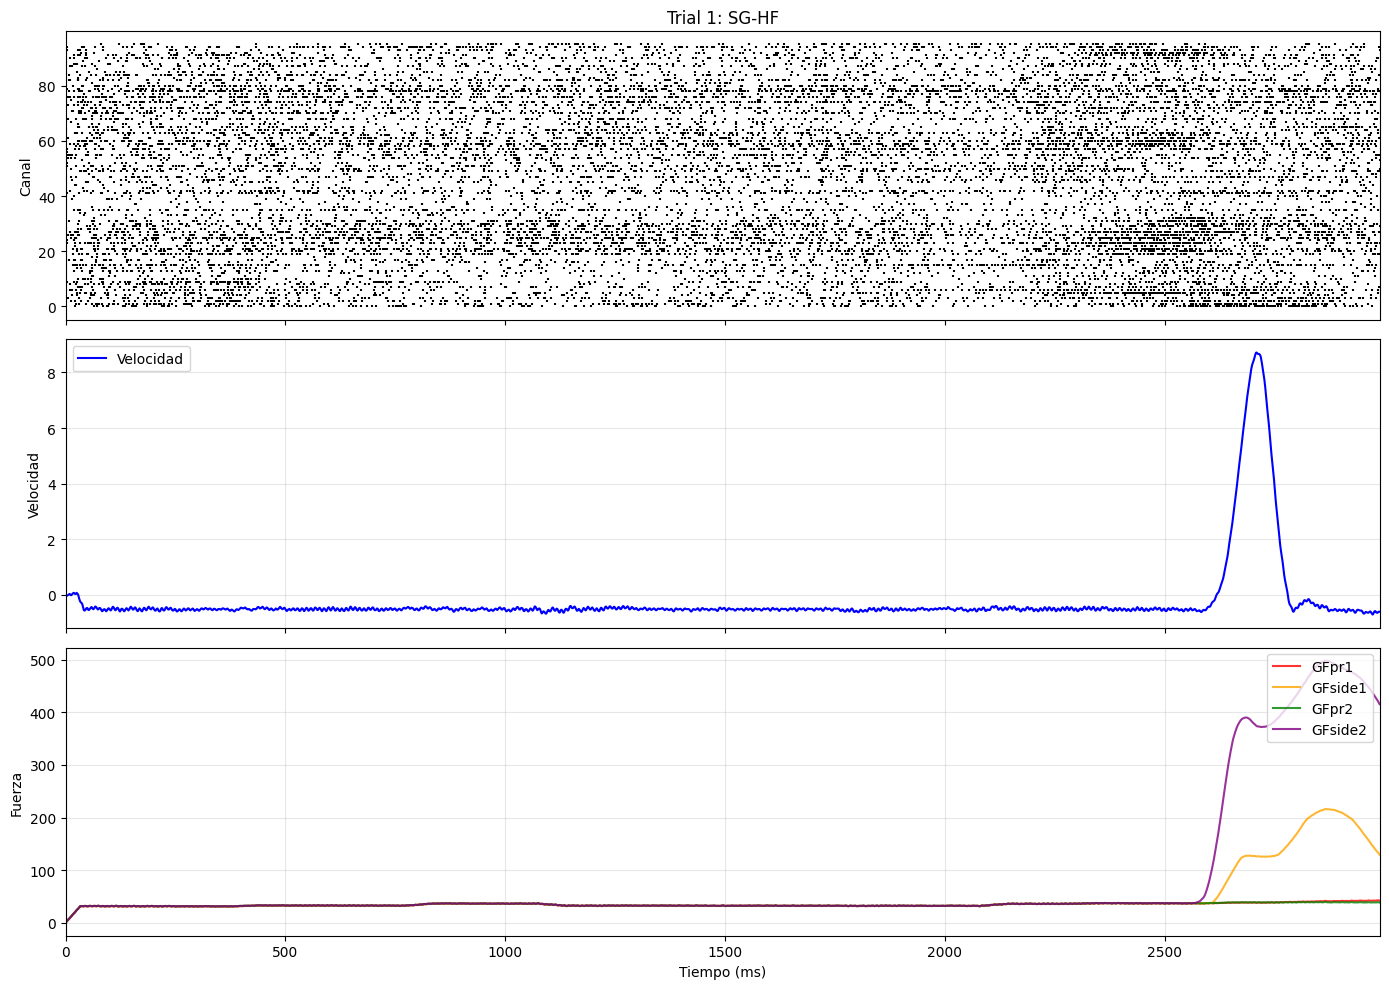

In [10]:
# ============================================================================
# CELDA 9: VISUALIZAR UN TRIAL DE EJEMPLO
# ============================================================================

trial_idx = 0  # Primer trial

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Panel 1: Raster plot del MUA
ax1 = axes[0]
mua = X_trials[trial_idx]  # (TRIAL_LENGTH, 96)
for ch in range(96):
    spike_times = np.where(mua[:, ch] > 0)[0]
    if len(spike_times) > 0:
        ax1.scatter(spike_times, [ch]*len(spike_times), s=1, c='black', marker='|')
ax1.set_ylabel('Canal')
ax1.set_title(f'Trial {trial_idx+1}: {df_trial_info.iloc[trial_idx]["grip_type"]}-{df_trial_info.iloc[trial_idx]["force_type"]}')
ax1.set_xlim(0, TRIAL_LENGTH)

# Panel 2: Velocidad
ax2 = axes[1]
time_ms = np.arange(TRIAL_LENGTH)
ax2.plot(time_ms, Y_trials[trial_idx, :, 0], 'b-', label='Velocidad')
ax2.set_ylabel('Velocidad')
ax2.legend()
ax2.grid(alpha=0.3)

# Panel 3: Fuerzas
ax3 = axes[2]
labels = ['GFpr1', 'GFside1', 'GFpr2', 'GFside2']
colors = ['red', 'orange', 'green', 'purple']
for i, (label, color) in enumerate(zip(labels, colors)):
    ax3.plot(time_ms, Y_trials[trial_idx, :, i+1], c=color, label=label, alpha=0.8)
ax3.set_xlabel('Tiempo (ms)')
ax3.set_ylabel('Fuerza')
ax3.legend(loc='upper right')
ax3.grid(alpha=0.3)

plt.tight_layout()
plt.show()



In [11]:
# ============================================================================
# CELDA 10: DATASET Y DATALOADERS
# ============================================================================
# CORREGIDO: split SECUENCIAL por trials (Paper Sec III-D, Martis), no random.

class TrialDataset(Dataset):
    def __init__(self, X, Y):
        self.X = torch.FloatTensor(X)
        self.Y = torch.FloatTensor(Y)

    def __len__(self): #devuleve el numero de trials(142)
        return len(self.X)

    def __getitem__(self, idx): #devuelve un trial especifico
        return self.X[idx], self.Y[idx]

# Crear dataset
dataset = TrialDataset(X_trials, Y_trials_norm)

# Split SECUENCIAL: 80% train / 10% val / 10% test (Paper Sec III-D)
n_total = len(dataset)
n_train = int(0.8 * n_total)
n_val   = int(0.1 * n_total)
n_test  = n_total - n_train - n_val

indices = list(range(n_total))
train_set = Subset(dataset, indices[:n_train])
val_set   = Subset(dataset, indices[n_train:n_train + n_val])
test_set  = Subset(dataset, indices[n_train + n_val:])

# DataLoaders (batch_size=10 como el paper)
batch_size = 10 #procesa 10 trials a la vez
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_set,   batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_set,  batch_size=batch_size, shuffle=False)


print(f"  Split SECUENCIAL por trials (Paper Sec III-D):")
print(f"  Total trials: {n_total}")
print(f"  Train: {n_train} (trials 0-{n_train-1})")
print(f"  Val:   {n_val} (trials {n_train}-{n_train+n_val-1})")
print(f"  Test:  {n_test} (trials {n_train+n_val}-{n_total-1})")
print(f"  Batch size: {batch_size}")
print(f"  Longitud de secuencia: {TRIAL_LENGTH} ms")

# Verifico un batch
bx, by = next(iter(train_loader))
print(f"\n  Batch ejemplo: X={bx.shape}, Y={by.shape}")

  Split SECUENCIAL por trials (Paper Sec III-D):
  Total trials: 142
  Train: 113 (trials 0-112)
  Val:   14 (trials 113-126)
  Test:  15 (trials 127-141)
  Batch size: 10
  Longitud de secuencia: 2990 ms

  Batch ejemplo: X=torch.Size([10, 2990, 96]), Y=torch.Size([10, 2990, 5])


# FASE 2: ARQUITECTURA SNN + LOOP ENTRENAMIENTO


In [12]:
# ============================================================================
# PASO 1: ARQUITECTURA SNN  (réplica fiel al paper / código de Martis)
# ============================================================================
# Topología: 96 → 64 → 128 → 64 → 5
# CORREGIDO respecto a versiones anteriores:
#   - bias=False en TODAS las capas Linear (Martis/paper, FPGA-friendly)
#   - β como TENSOR por neurona (no escalar por capa)

import snntorch as snn
from snntorch import surrogate
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {device}")

# Hiperparámetros
num_inputs = 96       # 96 electrodos Utah Array
num_hidden0 = 64      # Primera capa oculta
num_hidden1 = 128     # Segunda capa oculta
num_hidden2 = 64      # Tercera capa oculta
num_outputs = 5       # Dataset I: velocidad + 4 fuerzas

beta_init_value = 0.9       # Valor inicial de β (será entrenable, uno por neurona)
threshold_value = 0.1       # Umbral para generar spike
spike_grad = surrogate.fast_sigmoid()  # Gradiente surrogate para backprop

# β POR NEURONA (tensor, no escalar). Cada neurona aprende su propia constante de tiempo.
# Esto es lo que hace Martis por defecto ('1beta4layer': False).
beta_layer0 = torch.ones(num_hidden0) * beta_init_value
beta_layer1 = torch.ones(num_hidden1) * beta_init_value
beta_layer2 = torch.ones(num_hidden2) * beta_init_value
beta_layer3 = torch.ones(num_outputs) * beta_init_value

class Net(nn.Module):
    def __init__(self):
        super().__init__()

        # CAPA 0: 96 → 64  (bias=False, β por neurona)
        self.fc0 = nn.Linear(num_inputs, num_hidden0, bias=False)
        self.lif0 = snn.Leaky(beta=beta_layer0, learn_beta=True,
                              threshold=threshold_value, spike_grad=spike_grad,
                              reset_mechanism='subtract')

        # CAPA 1: 64 → 128
        self.fc1 = nn.Linear(num_hidden0, num_hidden1, bias=False)
        self.lif1 = snn.Leaky(beta=beta_layer1, learn_beta=True,
                              threshold=threshold_value, spike_grad=spike_grad,
                              reset_mechanism='subtract')

        # CAPA 2: 128 → 64
        self.fc2 = nn.Linear(num_hidden1, num_hidden2, bias=False)
        self.lif2 = snn.Leaky(beta=beta_layer2, learn_beta=True,
                              threshold=threshold_value, spike_grad=spike_grad,
                              reset_mechanism='subtract')

        # CAPA 3: 64 → 5 (salida SIN reset)
        self.fc3 = nn.Linear(num_hidden2, num_outputs, bias=False)
        self.lif3 = snn.Leaky(beta=beta_layer3, learn_beta=True,
                              threshold=threshold_value, spike_grad=spike_grad,
                              reset_mechanism='none')

    def forward(self, x):
        # x shape: [batch, tiempo, canales]
        batch_size = x.shape[0]
        num_steps = x.shape[1]

        # Inicializar potenciales de membrana
        mem0 = self.lif0.init_leaky()
        mem1 = self.lif1.init_leaky()
        mem2 = self.lif2.init_leaky()
        mem3 = self.lif3.init_leaky()

        # Lista para guardar salida de cada timestep
        mem3_rec = []

        # Recorrer secuencia temporal
        for step in range(num_steps):
            x_t = x[:, step, :]  # [batch, 96]

            # Capa 0
            cur0 = self.fc0(x_t)
            spk0, mem0 = self.lif0(cur0, mem0)

            # Capa 1
            cur1 = self.fc1(spk0)
            spk1, mem1 = self.lif1(cur1, mem1)

            # Capa 2
            cur2 = self.fc2(spk1)
            spk2, mem2 = self.lif2(cur2, mem2)

            # Capa 3 (salida) - guardamos potencial porque la salida es PREDICCION
            cur3 = self.fc3(spk2)
            _, mem3 = self.lif3(cur3, mem3)

            mem3_rec.append(mem3)

        # Stack: [batch, tiempo, 5]
        return torch.stack(mem3_rec, dim=1) # [batch, time, 5]

# Crear modelo
modelo = Net().to(device)

# Resumen de parámetros (verificación)
n_params = sum(p.numel() for p in modelo.parameters())
n_params_beta = sum(p.numel() for n, p in modelo.named_parameters() if 'beta' in n.lower() or 'recurrent' in n.lower())
print(f"  Parámetros totales del modelo: {n_params:,}")
print(f"  bias = False en todas las Linear (FPGA-friendly)")
print(f"  β por neurona: {num_hidden0}+{num_hidden1}+{num_hidden2}+{num_outputs} = {num_hidden0+num_hidden1+num_hidden2+num_outputs} β entrenables")

# Test forward pass (usando un batch del dataloader)
modelo.eval()
with torch.no_grad():
    test_x, test_y = next(iter(train_loader))
    test_x = test_x.to(device)
    test_out = modelo(test_x)

print(f"\n Test forward pass:")
print(f"  Input:  {test_x.shape} (=batch, tiempo, canales)")
print(f"  Output: {test_out.shape} (=batch, tiempo, targets)")

Dispositivo: cpu
  Parámetros totales del modelo: 23,109
  bias = False en todas las Linear (FPGA-friendly)
  β por neurona: 64+128+64+5 = 261 β entrenables

 Test forward pass:
  Input:  torch.Size([10, 2990, 96]) (=batch, tiempo, canales)
  Output: torch.Size([10, 2990, 5]) (=batch, tiempo, targets)


In [13]:
# ============================================================================
# PASO 2: CONFIGURACIÓN DE ENTRENAMIENTO
# ============================================================================

from scipy.stats import pearsonr

# Loss y optimizador
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(modelo.parameters(), lr=1e-3)

# Nombres de variables para métricas
VAR_NAMES = ['Velocity', 'GFpr1', 'GFside1', 'GFpr2', 'GFside2']

def compute_cc(pred, target):
    """Calcular Pearson Correlation Coefficient global (todas las variables juntas)."""
    pred_np = pred.detach().cpu().numpy().flatten()
    target_np = target.detach().cpu().numpy().flatten()
    if np.std(pred_np) < 1e-6 or np.std(target_np) < 1e-6:
        return 0.0
    cc, _ = pearsonr(pred_np, target_np)
    return cc if not np.isnan(cc) else 0.0

def compute_cc_per_variable(pred, target):
    """Calcular CC para cada una de las 5 variables por separado."""
    # pred/target shape: (n_trials, time, 5)
    pred_np = pred.detach().cpu().numpy()
    target_np = target.detach().cpu().numpy()
    
    ccs = []
    for i in range(5):
        p = pred_np[:, :, i].flatten()
        t = target_np[:, :, i].flatten()
        if np.std(p) < 1e-6 or np.std(t) < 1e-6:
            ccs.append(0.0)
        else:
            cc, _ = pearsonr(p, t)
            ccs.append(cc if not np.isnan(cc) else 0.0)
    
    return ccs  # Lista de 5 valores [CC_vel, CC_GFpr1, CC_GFside1, CC_GFpr2, CC_GFside2]

def train_epoch(model, loader, optimizer, loss_fn, device):
    """Entrenar una época."""
    model.train()
    total_loss = 0
    for batch_x, batch_y in loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)
        
        optimizer.zero_grad()
        output = model(batch_x)
        loss = loss_fn(output, batch_y)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    return total_loss / len(loader)

def validate_epoch(model, loader, loss_fn, device):
    """Validar una época. Devuelve loss, CC global, y CCs por variable."""
    model.eval()
    total_loss = 0
    all_preds, all_targets = [], []
    
    with torch.no_grad():
        for batch_x, batch_y in loader:
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)
            
            output = model(batch_x)
            loss = loss_fn(output, batch_y)
            total_loss += loss.item()
            
            all_preds.append(output)
            all_targets.append(batch_y)
    
    all_preds = torch.cat(all_preds, dim=0)
    all_targets = torch.cat(all_targets, dim=0)
    
    # CC global (para compatibilidad)
    cc_global = compute_cc(all_preds, all_targets)
    
    # CC por variable (nuevo)
    ccs_per_var = compute_cc_per_variable(all_preds, all_targets)
    
    return total_loss / len(loader), cc_global, ccs_per_var

print(f"  Loss: MSELoss")
print(f"  Optimizer: Adam (lr=1e-3)")
print(f"  Variables: {VAR_NAMES}")

  Loss: MSELoss
  Optimizer: Adam (lr=1e-3)
  Variables: ['Velocity', 'GFpr1', 'GFside1', 'GFpr2', 'GFside2']


In [14]:
# ============================================================================
# PASO 3: LOOP DE ENTRENAMIENTO (100 épocas)
# ============================================================================
# CORREGIDO: el mejor modelo es el de MENOR val_loss (Paper Sec III-D, Martis),
# no el de mayor val_cc.

num_epochs = 100
best_val_loss = float('inf')   # criterio del paper: menor val_loss
best_val_cc = -1               # se guarda solo para reporting
best_ccs = [0, 0, 0, 0, 0]
best_epoch = 0

# Historiales
loss_hist = {'train': [], 'val': []}
cc_hist = {'val': [], 'val_per_var': []}

print(f"{'='*110}")
print(f"ENTRENAMIENTO - {num_epochs} épocas (mejor modelo = menor val_loss, Paper Sec III-D)")
print(f"{'='*110}")
print(f"{'Época':>6} | {'Train Loss':>10} | {'Val Loss':>10} | {'Val CC':>8} | "
      f"{'Velocity':>8} | {'GFpr1':>8} | {'GFside1':>8} | {'GFpr2':>8} | {'GFside2':>8}")
print("-" * 110)

for epoch in range(num_epochs):
    train_loss = train_epoch(modelo, train_loader, optimizer, loss_fn, device)
    val_loss, val_cc, val_ccs = validate_epoch(modelo, val_loader, loss_fn, device)

    # Guardar historial
    loss_hist['train'].append(train_loss)
    loss_hist['val'].append(val_loss)
    cc_hist['val'].append(val_cc)
    cc_hist['val_per_var'].append(val_ccs)

    # Mejor modelo = MENOR val_loss (criterio del paper)
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_val_cc = val_cc
        best_ccs = val_ccs.copy()
        best_epoch = epoch + 1
        torch.save(modelo.state_dict(), 'best_model_exp07_definitivo.pth')
        marker = ' ✓'
    else:
        marker = ''

    # Imprimir cada 10 épocas, primera y última
    if (epoch + 1) % 10 == 0 or epoch == 0 or epoch == num_epochs - 1:
        print(f"{epoch+1:>6} | {train_loss:>10.4f} | {val_loss:>10.4f} | {val_cc:>8.4f} | "
              f"{val_ccs[0]:>8.4f} | {val_ccs[1]:>8.4f} | {val_ccs[2]:>8.4f} | "
              f"{val_ccs[3]:>8.4f} | {val_ccs[4]:>8.4f}{marker}")

print("-" * 110)
print(f"\n{'='*110}")
print("ENTRENAMIENTO COMPLETADO")
print(f"{'='*110}")
print(f"\nMejor modelo guardado en: best_model_exp07_definitivo.pth")
print(f"  Época del mejor modelo: {best_epoch}")
print(f"  Val Loss (mínimo):      {best_val_loss:.4f}")
print(f"  Val CC asociado:        {best_val_cc:.4f}")
print(f"\nMejor CC por variable (en la época de menor val_loss):")
print(f"  {'Velocity':>10}: {best_ccs[0]:.4f}")
print(f"  {'GFpr1':>10}: {best_ccs[1]:.4f}")
print(f"  {'GFside1':>10}: {best_ccs[2]:.4f}  {'← PROBLEMA' if best_ccs[2] < 0.3 else ''}")
print(f"  {'GFpr2':>10}: {best_ccs[3]:.4f}")
print(f"  {'GFside2':>10}: {best_ccs[4]:.4f}")

# Calcular métricas finales como el paper
VCC = best_ccs[0]
FCC = np.mean(best_ccs[1:5])
print(f"\n{'='*50}")
print(f"MÉTRICAS PAPER:")
print(f"  VCC (Velocity):     {VCC:.4f}  (paper: 0.87)")
print(f"  FCC (mean fuerzas): {FCC:.4f}  (paper: 0.87)")
print(f"{'='*50}")

ENTRENAMIENTO - 100 épocas (mejor modelo = menor val_loss, Paper Sec III-D)
 Época | Train Loss |   Val Loss |   Val CC | Velocity |    GFpr1 |  GFside1 |    GFpr2 |  GFside2
--------------------------------------------------------------------------------------------------------------
     1 |     2.4430 |     0.9688 |   0.0828 |   0.1950 |   0.1532 |  -0.0268 |   0.1324 |   0.0606 ✓
    10 |     0.6192 |     0.5449 |   0.5749 |   0.7694 |   0.6220 |   0.1554 |   0.7019 |   0.5628 ✓
    20 |     0.4768 |     0.5336 |   0.5741 |   0.8021 |   0.7407 |   0.1527 |   0.8550 |   0.5899
    30 |     0.3138 |     0.4282 |   0.7121 |   0.8275 |   0.7785 |   0.1605 |   0.8976 |   0.7767
    40 |     0.2631 |     0.4161 |   0.7145 |   0.8026 |   0.7797 |   0.1897 |   0.8959 |   0.8023
    50 |     0.2803 |     0.4108 |   0.7250 |   0.8222 |   0.7819 |   0.1696 |   0.9142 |   0.8235
    60 |     0.2427 |     0.4003 |   0.7246 |   0.8143 |   0.7923 |   0.1445 |   0.9216 |   0.8161
    70 |     0.33

# FASE 3: EVALUACION + RESULTADOS


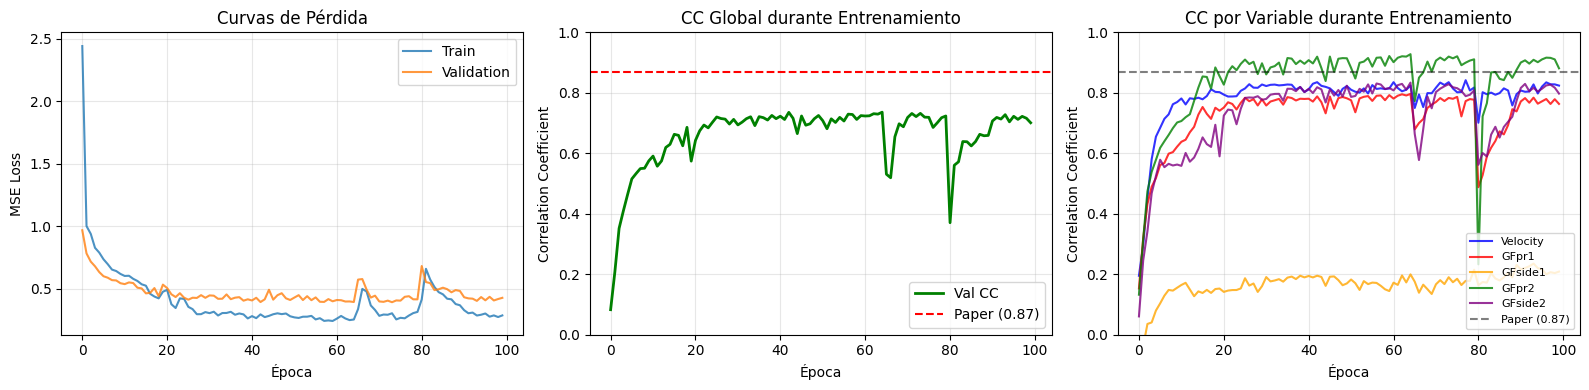


 Figura guardada: curvas_entrenamiento.png


In [15]:
# ============================================================================
# CELDA 15: VISUALIZAR CURVAS DE ENTRENAMIENTO
# ============================================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# --- Panel 1: Loss ---
axes[0].plot(loss_hist['train'], label='Train', alpha=0.8)
axes[0].plot(loss_hist['val'], label='Validation', alpha=0.8)
axes[0].set_xlabel('Época')
axes[0].set_ylabel('MSE Loss')
axes[0].set_title('Curvas de Pérdida')
axes[0].legend()
axes[0].grid(alpha=0.3)

# --- Panel 2: CC Global ---
axes[1].plot(cc_hist['val'], label='Val CC', color='green', linewidth=2)
axes[1].axhline(0.87, color='red', linestyle='--', label='Paper (0.87)')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Correlation Coefficient')
axes[1].set_title('CC Global durante Entrenamiento')
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[1].set_ylim([0, 1])

# --- Panel 3: CC por Variable ---
cc_per_var = np.array(cc_hist['val_per_var'])  # (n_epochs, 5)
colors = ['blue', 'red', 'orange', 'green', 'purple']
for i, (name, color) in enumerate(zip(VAR_NAMES, colors)):
    axes[2].plot(cc_per_var[:, i], label=name, color=color, alpha=0.8)
axes[2].axhline(0.87, color='black', linestyle='--', label='Paper (0.87)', alpha=0.5)
axes[2].set_xlabel('Época')
axes[2].set_ylabel('Correlation Coefficient')
axes[2].set_title('CC por Variable durante Entrenamiento')
axes[2].legend(loc='lower right', fontsize=8)
axes[2].grid(alpha=0.3)
axes[2].set_ylim([0, 1])

plt.tight_layout()
plt.savefig('curvas_entrenamiento.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n Figura guardada: curvas_entrenamiento.png")

In [16]:
# ============================================================================
# CELDA 16: EVALUACIÓN EN TEST SET
# ============================================================================

# Cargar mejor modelo
modelo.load_state_dict(torch.load('best_model_exp07_definitivo.pth'))
modelo.eval()


# Inferencia en test set
all_preds = []
all_targets = []

with torch.no_grad():
    for batch_x, batch_y in test_loader:
        batch_x = batch_x.to(device)
        output = modelo(batch_x)
        all_preds.append(output.cpu())
        all_targets.append(batch_y)

all_preds = torch.cat(all_preds, dim=0).numpy()
all_targets = torch.cat(all_targets, dim=0).numpy()

print(f"Predicciones: {all_preds.shape}")
print(f"Targets: {all_targets.shape}")

# Calcular CC por variable
print(f"\n{'='*60}")
print("RESULTADOS EN TEST SET")
print(f"{'='*60}")

cc_test = []
for i, name in enumerate(VAR_NAMES):
    pred_flat = all_preds[:, :, i].flatten()
    target_flat = all_targets[:, :, i].flatten()
    cc, _ = pearsonr(pred_flat, target_flat)
    cc_test.append(cc)
    
    # Indicador visual
    if cc >= 0.87:
        status = "🏆 Supera paper"
    elif cc >= 0.70:
        status = "✅ Bueno"
    elif cc >= 0.50:
        status = "⚠️ Moderado"
    else:
        status = "🚨 Bajo"
    
    print(f"  {name:12}: CC = {cc:.4f}  {status}")

# Métricas agregadas
VCC = cc_test[0]
FCC = np.mean(cc_test[1:])
FCC_sin_GFside1 = np.mean([cc_test[1], cc_test[3], cc_test[4]])

print(f"\n{'-'*60}")
print("MÉTRICAS AGREGADAS")
print(f"{'-'*60}")
print(f"  VCC (Velocity):           {VCC:.4f}  (Paper: 0.87)")
print(f"  FCC (4 fuerzas):          {FCC:.4f}  (Paper: 0.87)")
print(f"  FCC (sin GFside1):        {FCC_sin_GFside1:.4f}")
print(f"  CC Promedio (5 vars):     {np.mean(cc_test):.4f}")

Predicciones: (15, 2990, 5)
Targets: (15, 2990, 5)

RESULTADOS EN TEST SET
  Velocity    : CC = 0.8069  ✅ Bueno
  GFpr1       : CC = 0.5917  ⚠️ Moderado
  GFside1     : CC = 0.1955  🚨 Bajo
  GFpr2       : CC = 0.8146  ✅ Bueno
  GFside2     : CC = 0.8267  ✅ Bueno

------------------------------------------------------------
MÉTRICAS AGREGADAS
------------------------------------------------------------
  VCC (Velocity):           0.8069  (Paper: 0.87)
  FCC (4 fuerzas):          0.6071  (Paper: 0.87)
  FCC (sin GFside1):        0.7443
  CC Promedio (5 vars):     0.6471


## Coeficiente de determinacion (R2)

R2 por variable en el test, ademas del CC. El R2 mide que fraccion de la varianza del target explica la prediccion, y penaliza errores de escala y de sesgo, no solo la forma de la curva. El paper reporta VR2 = 0,71 y FR2 = 0,76 (sobre el test continuo).

In [17]:
# ============================================================================
# R2 (coeficiente de determinacion) en TEST
# ============================================================================
# R2 = 1 - SS_res/SS_tot. A diferencia del CC, el R2 SI penaliza errores de
# escala y de sesgo, no solo la forma. Se calcula sobre las mismas predicciones
# que el CC de la celda anterior (all_preds, all_targets).
# AVISO: el paper reporta VR2/FR2 sobre el TEST CONTINUO; esto es flatten y por
# grip (coherente con el CC de este notebook). El R2 continuo esta en exp_08.
import numpy as np

def r2_score(pred, target):
    pred = np.asarray(pred); target = np.asarray(target)
    ss_res = np.sum((target - pred) ** 2)
    ss_tot = np.sum((target - target.mean()) ** 2)
    return 1.0 - ss_res / ss_tot if ss_tot > 1e-12 else float('nan')

print('=' * 60)
print('R2 EN TEST (flatten, mismas predicciones que el CC)')
print('=' * 60)
r2_test = []
for i, name in enumerate(VAR_NAMES):
    p = all_preds[:, :, i].flatten()
    t = all_targets[:, :, i].flatten()
    r2 = r2_score(p, t)
    r2_test.append(r2)
    print(f'  {name:12}: R2 = {r2:.4f}')

VR2 = r2_test[0]
FR2 = np.mean(r2_test[1:])
print(f'\nVR2 (Velocity):  {VR2:.4f}  (Paper: 0.71)')
print(f'FR2 (4 fuerzas): {FR2:.4f}  (Paper: 0.76)')

# R2 por grip: cada fuerza medida solo en su tipo de agarre (como el CC por grip)
try:
    idx_test = test_set.indices
    grip = df_correct.iloc[idx_test]['grip_type'].values
    mask = {'SG': grip == 'SG', 'PG': grip == 'PG'}
    print('\nR2 por grip (cada variable en su tipo de trial):')
    print(f"{'Variable':12}{'SG':>10}{'PG':>10}")
    for i, name in enumerate(VAR_NAMES):
        vals = {}
        for g in ('SG', 'PG'):
            if mask[g].sum() > 0:
                pg = all_preds[mask[g]].reshape(-1, 5)[:, i]
                tg = all_targets[mask[g]].reshape(-1, 5)[:, i]
                vals[g] = r2_score(pg, tg)
            else:
                vals[g] = float('nan')
        print(f'{name:12}{vals["SG"]:>10.4f}{vals["PG"]:>10.4f}')
except NameError:
    print('\n(Para el R2 por grip, ejecuta antes las celdas que definen test_set y df_correct.)')

R2 EN TEST (flatten, mismas predicciones que el CC)
  Velocity    : R2 = 0.6350
  GFpr1       : R2 = 0.2779
  GFside1     : R2 = 0.0206
  GFpr2       : R2 = 0.6166
  GFside2     : R2 = 0.6668

VR2 (Velocity):  0.6350  (Paper: 0.71)
FR2 (4 fuerzas): 0.3954  (Paper: 0.76)

R2 por grip (cada variable en su tipo de trial):
Variable            SG        PG
Velocity        0.7930    0.3810
GFpr1          -0.1080    0.2598
GFside1         0.1125   -0.0503
GFpr2          -1.3045    0.6389
GFside2         0.8695   -0.3506


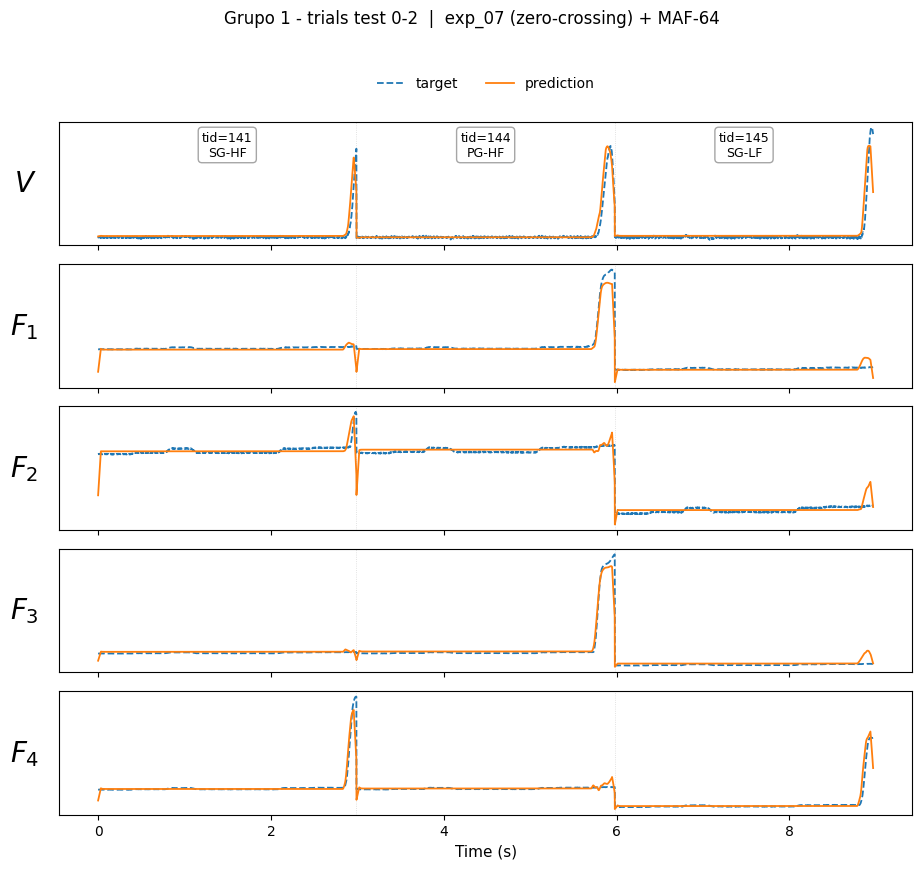

Guardado: fig_exp07_grupo1_trials_0-2.png


In [18]:
# ============================================================================
# CELDA 17: VISUALIZAR PREDICCIONES vs TARGETS (estilo Figura 5 del paper)
# ============================================================================
# Reconstruyo unidades fisicas: des-normalizo y sumo el offset del zero-crossing
# (Y_initials) que reste a cada trial. Aplico MAF-64 a la prediccion para una
# comparacion justa (el target ya viene suavizado con MAF-64). Estilo paper:
# target azul discontinuo, prediccion naranja solido, etiquetas V/F1..F4.

def _denorm(arr_norm, params):
    if params['tipo'] == 'zscore':
        arr = arr_norm * params['std'] + params['mean']
    elif params['tipo'] == 'minmax':
        arr = arr_norm * (params['max'] - params['min']) + params['min']
    else:
        arr = arr_norm.copy()
    return arr + params['baseline']

idx_test = list(test_set.indices)
meta_test = df_trial_info.iloc[idx_test].reset_index(drop=True)
Y_init_test = Y_initials[idx_test]

pred_abs = _denorm(all_preds,   norm_params) + Y_init_test[:, None, :]
targ_abs = _denorm(all_targets, norm_params) + Y_init_test[:, None, :]

def maf_along_time(arr3d, n=64):
    kernel = np.ones(n) / n
    out = np.zeros_like(arr3d)
    for k in range(arr3d.shape[0]):
        for v in range(arr3d.shape[2]):
            out[k, :, v] = np.convolve(arr3d[k, :, v], kernel, mode='same')
    return out
pred_abs = maf_along_time(pred_abs, 64)

SHORT_LABELS = ['V', r'$F_1$', r'$F_2$', r'$F_3$', r'$F_4$']

def plot_3trials(local_idx, titulo, fname):
    pred_c = np.concatenate([pred_abs[k] for k in local_idx], axis=0)
    targ_c = np.concatenate([targ_abs[k] for k in local_idx], axis=0)
    t_ax = np.arange(pred_c.shape[0]) / 1000.0
    fig, axes = plt.subplots(5, 1, figsize=(11, 9), sharex=True)
    fig.subplots_adjust(hspace=0.15)
    starts = []; acc = 0
    for k in local_idx:
        starts.append(acc); acc += pred_abs.shape[1]
    ends = starts[1:] + [acc]
    for i, (ax, lbl) in enumerate(zip(axes, SHORT_LABELS)):
        ax.plot(t_ax, targ_c[:, i], 'tab:blue', ls='--', lw=1.3, label='target' if i == 0 else None)
        ax.plot(t_ax, pred_c[:, i], 'tab:orange', ls='-', lw=1.3, label='prediction' if i == 0 else None)
        for ts in starts[1:]:
            ax.axvline(ts / 1000.0, color='gray', alpha=0.3, lw=0.6, ls=':')
        ax.set_ylabel(lbl, fontsize=20, fontstyle='italic', rotation=0, labelpad=25, va='center')
        ax.set_yticks([]); ax.grid(False)
    for ts, te, k in zip(starts, ends, local_idx):
        m = meta_test.iloc[k]
        label = f"tid={m['trial_id']}\n{m['grip_type']}-{m['force_type']}"
        axes[0].text(((ts + te) / 2.0) / 1000.0, axes[0].get_ylim()[1] * 0.92, label,
                     ha='center', va='top', fontsize=9,
                     bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray', alpha=0.7))
    axes[-1].set_xlabel('Time (s)', fontsize=11)
    axes[0].legend(loc='lower center', bbox_to_anchor=(0.5, 1.15), ncol=2, frameon=False)
    fig.suptitle(titulo, y=1.005)
    plt.savefig(fname, dpi=180, bbox_inches='tight')
    plt.show()
    print(f"Guardado: {fname}")

# Grupo 1: primeros 3 trials del test
plot_3trials([0, 1, 2], "Grupo 1 - trials test 0-2  |  exp_07 (zero-crossing) + MAF-64",
             "fig_exp07_grupo1_trials_0-2.png")


Un trial por tipo: {'SG-HF': 0, 'SG-LF': 2, 'PG-HF': 1, 'PG-LF': 4}


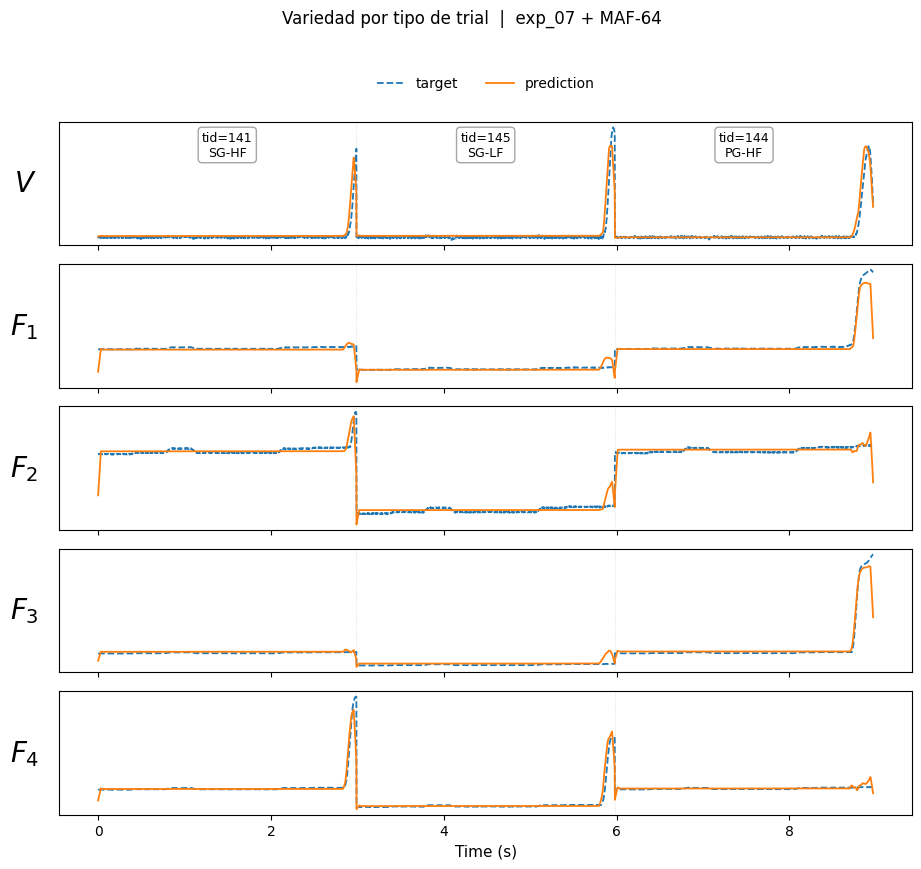

Guardado: fig_exp07_un_trial_por_tipo.png


In [19]:
# ============================================================================
# CELDA 18: UN TRIAL POR TIPO (variedad SG-HF, SG-LF, PG-HF)
# ============================================================================
tipos = {'SG-HF': None, 'SG-LF': None, 'PG-HF': None, 'PG-LF': None}
for k in range(len(meta_test)):
    key = f"{meta_test.iloc[k]['grip_type']}-{meta_test.iloc[k]['force_type']}"
    if key in tipos and tipos[key] is None:
        tipos[key] = k
print(f"Un trial por tipo: {tipos}")
disponibles = [v for v in tipos.values() if v is not None]
if len(disponibles) >= 3:
    plot_3trials(disponibles[:3], "Variedad por tipo de trial  |  exp_07 + MAF-64",
                 "fig_exp07_un_trial_por_tipo.png")


In [20]:
# ============================================================================
# ANÁLISIS POR TIPO DE GRIP: CC de cada variable según el tipo de trial
# ============================================================================
from scipy.stats import pearsonr

# 1. Recuperar los índices del test set y sus tipos de grip
indices_test = test_set.indices
grip_types_test = df_correct.iloc[indices_test]['grip_type'].values
print(f"Trials en test: {len(indices_test)}")
print(f"  Side grip (SG):      {(grip_types_test == 'SG').sum()}")
print(f"  Precision grip (PG): {(grip_types_test == 'PG').sum()}")

# 2. Calcular CC por tipo de trial (cada fuerza se mide bien en su agarre)
mask_sg = (grip_types_test == 'SG')
mask_pg = (grip_types_test == 'PG')
preds_sg = all_preds[mask_sg].reshape(-1, 5); targets_sg = all_targets[mask_sg].reshape(-1, 5)
preds_pg = all_preds[mask_pg].reshape(-1, 5); targets_pg = all_targets[mask_pg].reshape(-1, 5)

# 3. Tabla comparativa: TODOS vs solo SG vs solo PG
print()
print(f"{'Variable':<10s} {'TODOS':>10s} {'Solo SG':>10s} {'Solo PG':>10s}")
print("-" * 45)
for i, name in enumerate(var_names):
    cc_sg, _ = pearsonr(preds_sg[:, i], targets_sg[:, i])
    cc_pg, _ = pearsonr(preds_pg[:, i], targets_pg[:, i])
    print(f"{name:<10s} {cc_test[i]:>10.4f} {cc_sg:>10.4f} {cc_pg:>10.4f}")


Trials en test: 15
  Side grip (SG):      7
  Precision grip (PG): 8

Variable        TODOS    Solo SG    Solo PG
---------------------------------------------
Velocity       0.8069     0.8913     0.7056
GFpr1          0.5917     0.1170     0.6069
GFside1        0.1955     0.5223    -0.0316
GFpr2          0.8146     0.0916     0.8215
GFside2        0.8267     0.9386    -0.0006
